In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

#### 3.1 Object tracking using the mean-shift method

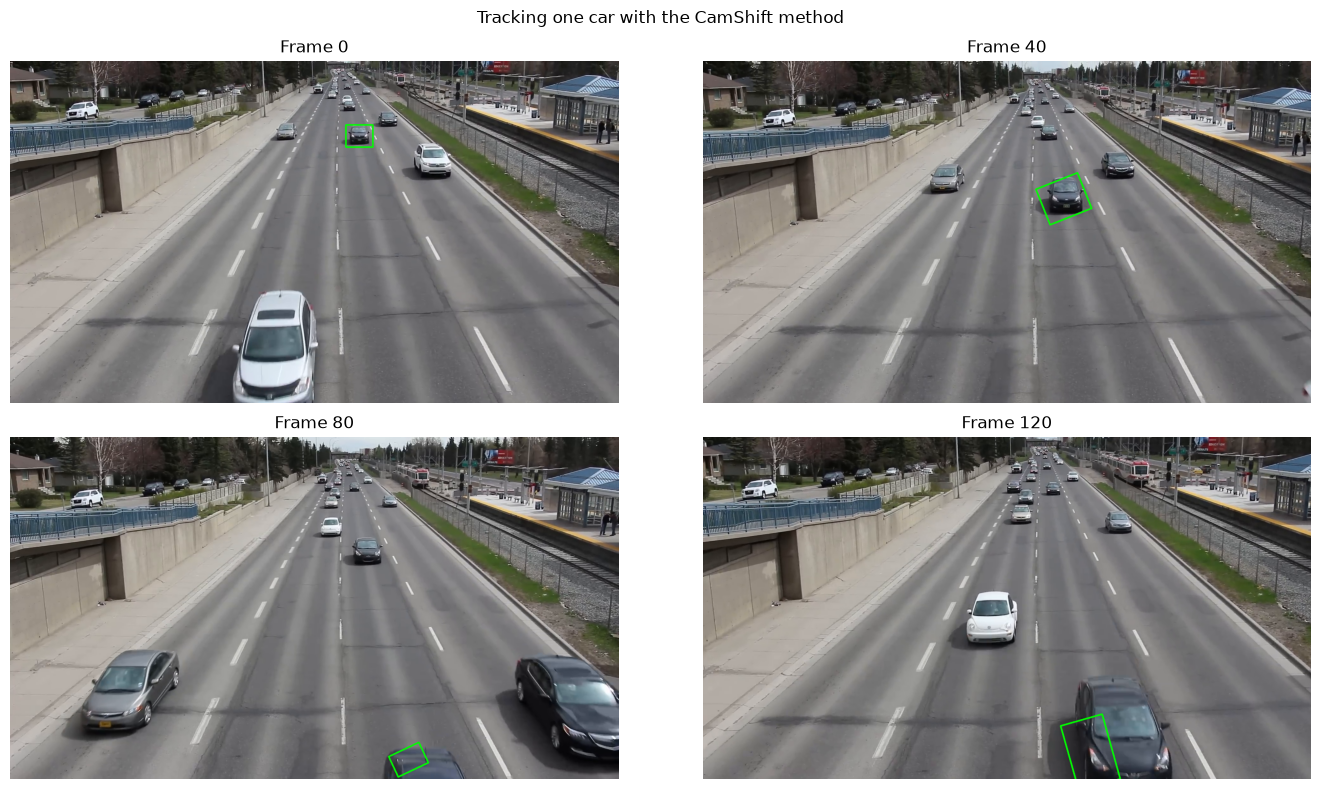

In [2]:
video_path = "images/cars-moving.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Unable to open video: {video_path}")

ret, first_frame = cap.read()
if not ret:
    cap.release()
    raise RuntimeError("Unable to read the first video frame")

# ROI of one dark car in the center lane of the first frame:
# x, y, width, height
x, y, width, height = 1059, 202, 85, 70
track_window = (x, y, width, height)

frame_height, frame_width = first_frame.shape[:2]
if x + width > frame_width or y + height > frame_height:
    cap.release()
    raise ValueError("The initial ROI is outside the frame")

# Histogram of the selected car based on HSV hue and saturation.
roi = first_frame[y:y + height, x:x + width]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(
    hsv_roi,
    np.array((0, 30, 20), dtype=np.uint8),
    np.array((180, 255, 255), dtype=np.uint8),
)
roi_hist = cv2.calcHist([hsv_roi], [0, 1], mask, [180, 256], [0, 180, 0, 256])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

# CamShift automatically changes the bounding box size as the car scale changes.
selected_indices = {0, 40, 80, 120}
tracked_frames = []
frame_index = 0

while True:
    if frame_index == 0:
        frame = first_frame
    else:
        ret, frame = cap.read()
        if not ret:
            break

    if frame_index > 0:
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        back_projection = cv2.calcBackProject(
            [hsv], [0, 1], roi_hist, [0, 180, 0, 256], 1
        )
        rotated_box, track_window = cv2.CamShift(
            back_projection, track_window, term_crit
        )

    if frame_index in selected_indices:
        box_points = cv2.boxPoints(rotated_box) if frame_index > 0 else np.array(
            [[x, y], [x + width, y], [x + width, y + height], [x, y + height]],
            dtype=np.float32,
        )
        box_points = np.int32(box_points)
        marked_frame = frame.copy()
        cv2.polylines(
            marked_frame,
            [box_points],
            True,
            (0, 255, 0),
            3,
        )
        tracked_frames.append(
            (frame_index, cv2.cvtColor(marked_frame, cv2.COLOR_BGR2RGB))
        )

    if len(tracked_frames) == len(selected_indices):
        break

    frame_index += 1

cap.release()

if len(tracked_frames) != len(selected_indices):
    raise RuntimeError("The video is too short to display four frames")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (current_index, marked_frame) in zip(axes.ravel(), tracked_frames):
    ax.imshow(marked_frame)
    ax.set_title(f"Frame {current_index}")
    ax.axis("off")

fig.suptitle("Tracking one car with the CamShift method")
plt.tight_layout()
plt.show()

#### 3.2 Definition of a gesture (you need a web camera, to close the camera window press Q)

In [10]:
# Install once in the notebook environment if MediaPipe is not available:
# %pip install mediapipe

import math
import time
import urllib.request
from pathlib import Path

import mediapipe as mp
from mediapipe.tasks.python import BaseOptions
from mediapipe.tasks.python.vision import (
    HandLandmarker,
    HandLandmarkerOptions,
    RunningMode,
)

# Optional Windows-only system volume control.
try:
    from ctypes import POINTER, cast
    from comtypes import CLSCTX_ALL
    from pycaw.pycaw import AudioUtilities, IAudioEndpointVolume
except ImportError:
    volume = None
else:
    devices = AudioUtilities.GetSpeakers()
    interface = devices.Activate(
        IAudioEndpointVolume._iid_, CLSCTX_ALL, None
    )
    volume = cast(interface, POINTER(IAudioEndpointVolume))
    min_volume, max_volume = volume.GetVolumeRange()[:2]

# MediaPipe 1.x replaced mediapipe.solutions with the Tasks API,
# which needs a model file downloaded once.
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/latest/hand_landmarker.task"
)
model_path = Path("hand_landmarker.task")
if not model_path.exists():
    urllib.request.urlretrieve(MODEL_URL, model_path)

hand_landmarker = HandLandmarker.create_from_options(
    HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(model_path)),
        running_mode=RunningMode.VIDEO,
        num_hands=1,
        min_hand_detection_confidence=0.7,
        min_tracking_confidence=0.7,
    )
)

camera = cv2.VideoCapture(0)
if not camera.isOpened():
    raise RuntimeError("Unable to open the camera")

previous_time = time.time()
try:
    while True:
        success, frame = camera.read()
        if not success:
            print("Unable to read a frame from the camera")
            break

        frame = cv2.flip(frame, 1)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        timestamp_ms = int(time.time() * 1000)
        result = hand_landmarker.detect_for_video(mp_image, timestamp_ms)

        if result.hand_landmarks:
            hand_landmarks = result.hand_landmarks[0]
            height, width = frame.shape[:2]

            # Landmark 4 is the thumb tip; landmark 8 is the index finger tip.
            thumb = hand_landmarks[4]
            index = hand_landmarks[8]
            thumb_point = (int(thumb.x * width), int(thumb.y * height))
            index_point = (int(index.x * width), int(index.y * height))

            distance = math.hypot(
                index_point[0] - thumb_point[0],
                index_point[1] - thumb_point[1],
            )
            volume_percent = int(np.interp(distance, [30, 250], [0, 100]))
            volume_percent = int(np.clip(volume_percent, 0, 100))

            if volume is not None:
                volume_level = np.interp(
                    distance, [30, 250], [min_volume, max_volume]
                )
                volume.SetMasterVolumeLevel(float(volume_level), None)

            cv2.line(frame, thumb_point, index_point, (255, 0, 255), 3)
            cv2.circle(frame, thumb_point, 12, (0, 255, 0), cv2.FILLED)
            cv2.circle(frame, index_point, 12, (0, 255, 0), cv2.FILLED)
            cv2.putText(
                frame,
                f"Distance: {int(distance)} px",
                (20, 45),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 255, 255),
                2,
            )
            cv2.putText(
                frame,
                f"Gesture value: {volume_percent}%",
                (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2,
            )
            for landmark in hand_landmarks:
                point = (int(landmark.x * width), int(landmark.y * height))
                cv2.circle(frame, point, 3, (255, 0, 0), cv2.FILLED)

        current_time = time.time()
        fps = 1 / max(current_time - previous_time, 1e-6)
        previous_time = current_time
        cv2.putText(
            frame,
            f"FPS: {int(fps)} | Press q to quit",
            (20, frame.shape[0] - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (255, 255, 255),
            2,
        )

        cv2.imshow("Thumb-index distance", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
        # Detect the window being closed via the "X" button, not just the "q" key.
        if cv2.getWindowProperty("Thumb-index distance", cv2.WND_PROP_VISIBLE) < 1:
            break
finally:
    camera.release()
    hand_landmarker.close()
    try:
        cv2.destroyAllWindows()
    except cv2.error:
        pass  # The window may already be closed by the user.

W0000 00:00:1789656037.192021  144068 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789656037.201592  144068 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


#### 3.3 Analysis of partial and full optical flow between image frames

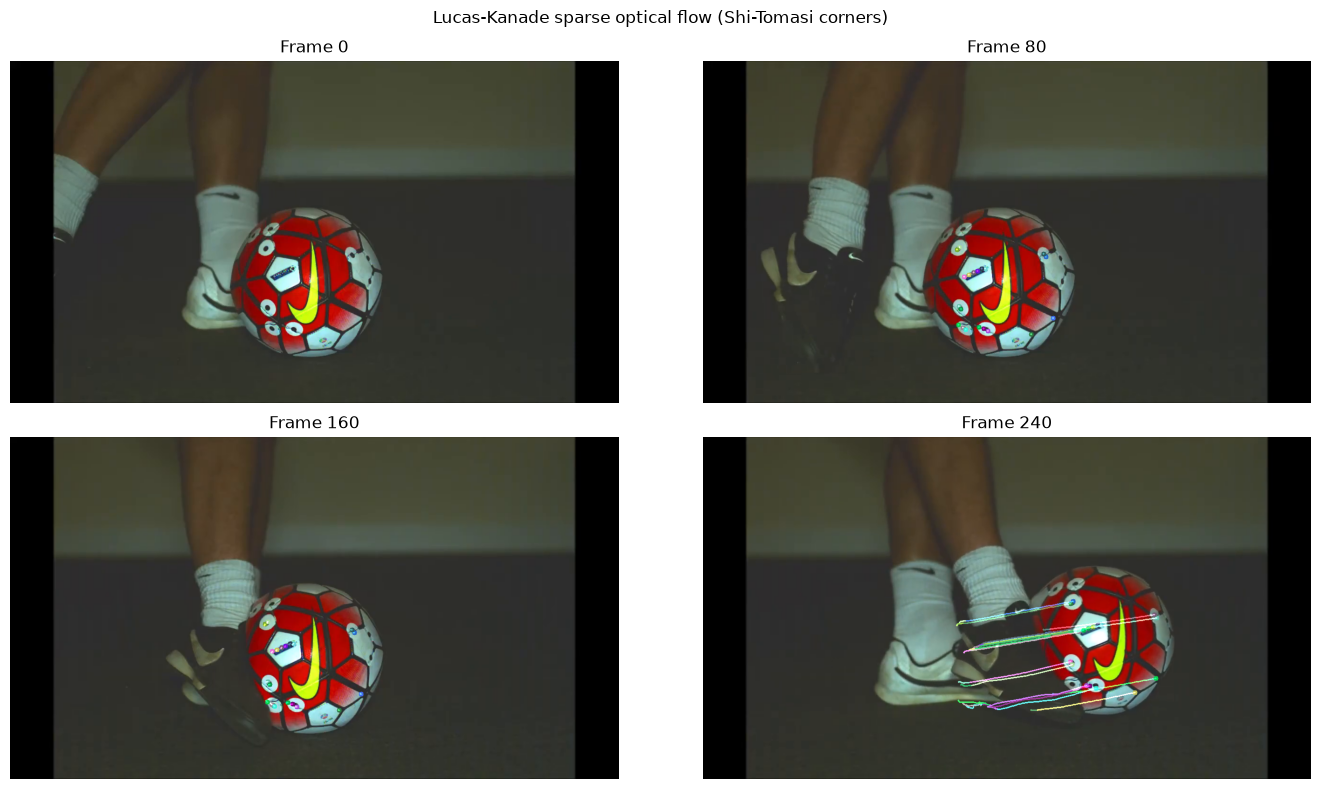

In [12]:
video_path = "images/ball-kick.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Unable to open video: {video_path}")

# Parameters for the Shi-Tomasi corner detector.
shi_tomasi_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7,
)
# Parameters for the Lucas-Kanade optical flow.
lucas_kanade_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
)

# Random colors used to draw each tracked point's trail.
colors = np.random.randint(0, 255, (100, 3))

# Read the first frame and find its Shi-Tomasi corners to track.
ret, old_frame = cap.read()
if not ret:
    cap.release()
    raise RuntimeError("Unable to read the first video frame")

old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **shi_tomasi_params)

# Mask image used to accumulate the motion trails across frames.
trails_mask = np.zeros_like(old_frame)

# Snapshot the accumulated trails at 4 evenly spaced frames: start, two
# intermediate points, and the end of the motion.
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
selected_indices = set(np.linspace(0, frame_count - 1, 4, dtype=int).tolist())
snapshots = []
frame_index = 0

if frame_index in selected_indices:
    snapshots.append((frame_index, cv2.cvtColor(old_frame, cv2.COLOR_BGR2RGB)))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_index += 1
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # calcOpticalFlowPyrLK implements the Lucas-Kanade method to find
    # the new position of each tracked point (partial optical flow).
    p1, status, error = cv2.calcOpticalFlowPyrLK(
        old_gray, frame_gray, p0, None, **lucas_kanade_params
    )

    if p1 is None:
        break

    # Keep only the points that were successfully tracked.
    good_new = p1[status == 1]
    good_old = p0[status == 1]

    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        color = colors[i].tolist()
        trails_mask = cv2.line(
            trails_mask, (int(a), int(b)), (int(c), int(d)), color, 2
        )
        frame = cv2.circle(frame, (int(a), int(b)), 5, color, -1)

    last_frame_with_points = cv2.add(frame, trails_mask)

    if frame_index in selected_indices:
        snapshots.append(
            (frame_index, cv2.cvtColor(last_frame_with_points, cv2.COLOR_BGR2RGB))
        )

    # Update the previous frame and previous points for the next iteration.
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

cap.release()

if len(snapshots) < 4:
    raise RuntimeError(f"Only {len(snapshots)} snapshots were captured, expected 4")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (current_index, snapshot) in zip(axes.ravel(), snapshots[:4]):
    ax.imshow(snapshot)
    ax.set_title(f"Frame {current_index}")
    ax.axis("off")

fig.suptitle("Lucas-Kanade sparse optical flow (Shi-Tomasi corners)")
plt.tight_layout()
plt.show()

#### 3.4 Face recognition using Haar cascades

In [17]:
import urllib.request
from pathlib import Path

# This OpenCV build ships without bundled Haar cascade data files,
# so download the official cascade once if it's not available locally.
CASCADE_URL = (
    "https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/"
    "haarcascade_frontalface_default.xml"
)
cascade_path = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"
if not cascade_path.exists():
    cascade_path = Path("haarcascade_frontalface_default.xml")
    if not cascade_path.exists():
        urllib.request.urlretrieve(CASCADE_URL, cascade_path)

face_cascade = cv2.CascadeClassifier(str(cascade_path))
if face_cascade.empty():
    raise RuntimeError(f"Unable to load the Haar cascade from {cascade_path}")


def blur_face(img):
    (h, w) = img.shape[:2]
    dW = int(w / 2)
    dH = int(h / 2)
    if dW % 2 == 0:
        dW -= 1
    if dH % 2 == 0:
        dH -= 1
    blurred = cv2.GaussianBlur(img, (dW, dH), 0)
    return cv2.GaussianBlur(blurred, (dW, dH), 0)


camera = cv2.VideoCapture(0)
if not camera.isOpened():
    raise RuntimeError("Unable to open the camera")

try:
    while True:
        success, frame = camera.read()
        if not success:
            print("Unable to read a frame from the camera")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
        )

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
            frame[y:y + h, x:x + w] = blur_face(frame[y:y + h, x:x + w])

        cv2.putText(
            frame,
            "Press q to quit",
            (20, frame.shape[0] - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (255, 255, 255),
            2,
        )

        cv2.imshow("video", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
        # Detect the window being closed via the "X" button, not just the "q" key.
        if cv2.getWindowProperty("video", cv2.WND_PROP_VISIBLE) < 1:
            break
finally:
    camera.release()
    try:
        cv2.destroyAllWindows()
    except cv2.error:
        pass  # The window may already be closed by the user.